<a href="https://colab.research.google.com/github/donatelk/kgdneuro265/blob/main/homework/coding_homework_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Kelsey Donatelli
*Neuro 265*

**4/3/2026**

In [14]:
#Import Packages
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [15]:
#Import data as numpy arrays
spikes_L_1_url= 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_left_trial1.csv'
spikes_R_1_url= 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_right_trial1.csv'
spikes_L_2_url= 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_left_trial2.csv'
spikes_R_2_url= 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_right_trial2.csv'

spikes_left_trial1= np.loadtxt(spikes_L_1_url, delimiter= ',')
spikes_right_trial1= np.loadtxt(spikes_R_1_url, delimiter= ',')
spikes_left_trial2= np.loadtxt(spikes_L_2_url, delimiter= ',')
spikes_right_trial2= np.loadtxt(spikes_R_2_url, delimiter= ',')

In [16]:
#Length of each array
print(len(spikes_left_trial1))
print(len(spikes_right_trial1))
print(len(spikes_left_trial2))
print(len(spikes_right_trial2))

65
45
53
69


In [17]:
#Determine the firing rate of the neuron during each trial
print(len(spikes_left_trial1)/spikes_left_trial1[-1])
print(len(spikes_right_trial1)/spikes_right_trial1[-1])
print(len(spikes_left_trial2)/spikes_left_trial2[-1])
print(len(spikes_right_trial2)/spikes_right_trial2[-1])

2.191706474799961
1.5018790008179232
1.7772956053046305
2.6404345742023723


The neuron fires more before right hand turns in trial one, and left hand turns in trial 2.

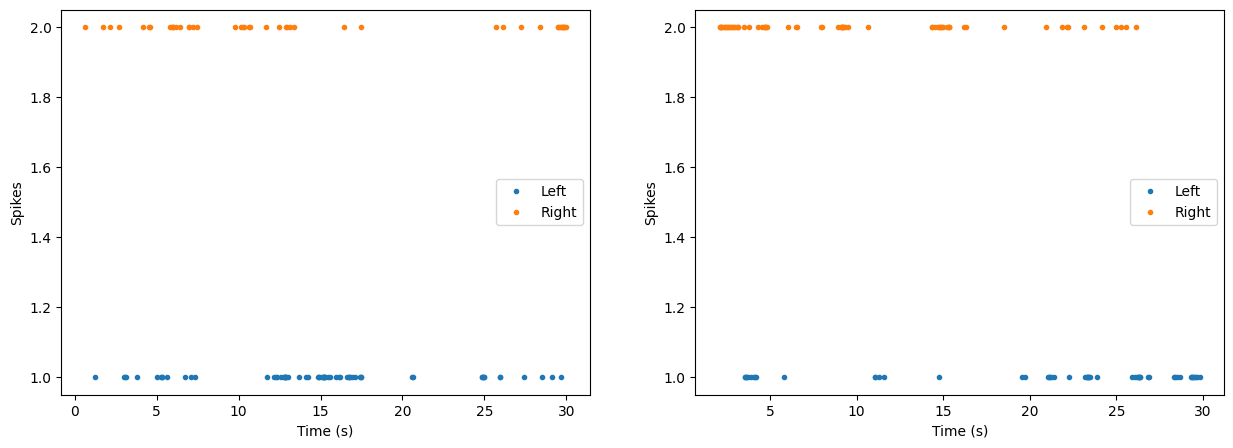

In [18]:
#Plots of spike train data
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0]. plot(spikes_left_trial1, np.ones_like(spikes_left_trial1), '.')
ax[0].plot(spikes_right_trial1, 2* np.ones_like(spikes_right_trial1), '.')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Spikes')
ax[0].legend({'Left', 'Right'})

ax[1].plot(spikes_left_trial2, np.ones_like(spikes_left_trial2), '.')
ax[1].plot(spikes_right_trial2, 2* np.ones_like(spikes_right_trial2), '.')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Spikes')
ax[1].legend({'Left', 'Right'})


The neuron seems to be more bursty during left trials, with breaks in firing at 10 and 20 seconds in trial one, and break at 7 and 17 seconds in trial 2. The neurons seems to show slightly more consistent firiing during right trials.

In [19]:
#ISI arrays
ISI_left_1= np.diff(spikes_left_trial1)
ISI_right_1= np.diff(spikes_right_trial1)
ISI_left_2= np.diff(spikes_left_trial2)
ISI_right_2= np.diff(spikes_right_trial2)

Text(0.5, 1.0, 'Right Turn Trial 2')

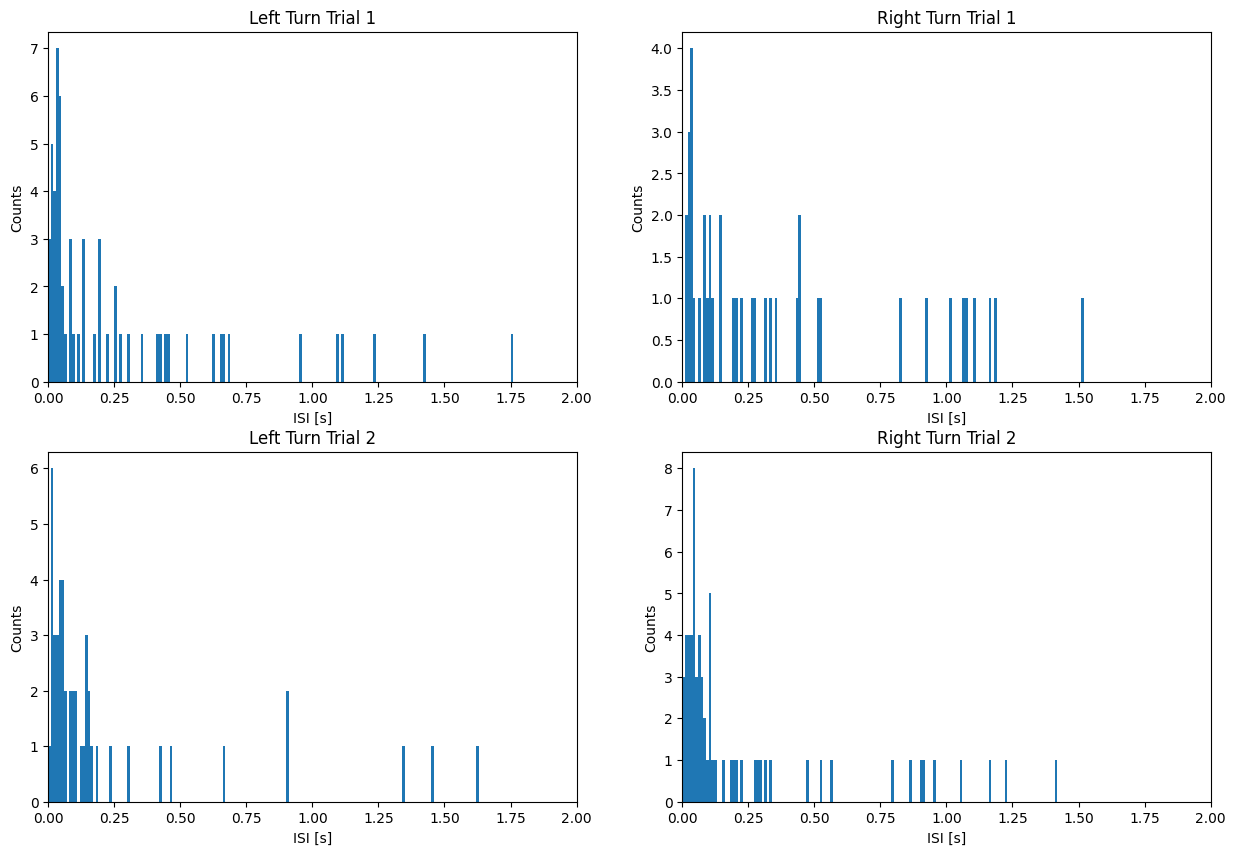

In [20]:
#Histograms of the 4 ISI arrays
fig, ax = plt.subplots(2,2,figsize=(15,10))
bins= np.arange(0,2,0.01)

ax[0,0].hist(ISI_left_1, bins)
ax[0,0].set_xlim([0,2])
ax[0,0].set_xlabel('ISI [s]')
ax[0,0].set_ylabel('Counts')
ax[0,0].set_title('Left Turn Trial 1')


ax[1,0].hist(ISI_left_2, bins)
ax[1,0].set_xlim([0,2])
ax[1,0].set_xlabel('ISI [s]')
ax[1,0].set_ylabel('Counts')
ax[1,0].set_title('Left Turn Trial 2')

ax[0,1].hist(ISI_right_1, bins)
ax[0,1].set_xlim([0,2])
ax[0,1].set_xlabel('ISI [s]')
ax[0,1].set_ylabel('Counts')
ax[0,1].set_title('Right Turn Trial 1')

ax[1,1].hist(ISI_right_2, bins)
ax[1,1].set_xlim([0,2])
ax[1,1].set_xlabel('ISI [s]')
ax[1,1].set_ylabel('Counts')
ax[1,1].set_title('Right Turn Trial 2')



These histograms show that the neurons tends to be more burtsy during left turn trials, with higher counts at lower ISIs and a few more spread out counts. The right turn trials show a slightly more spread out concentration of ISIs.

Text(0.5, 1.0, 'Trial 2')

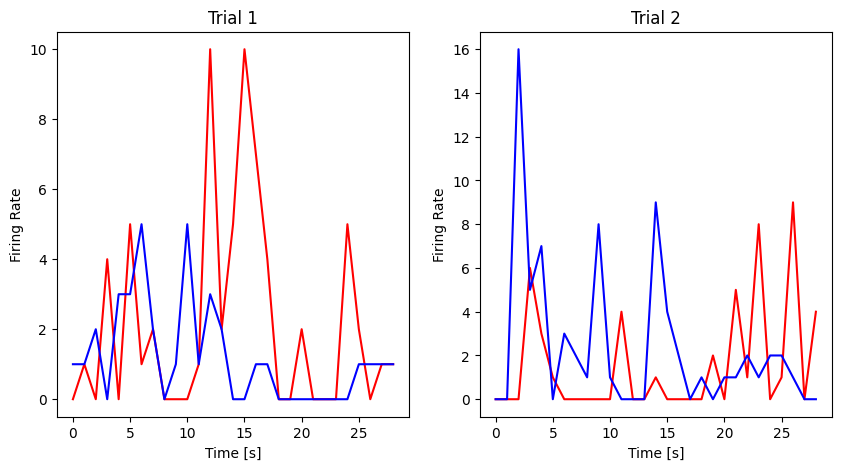

In [22]:
#Calculate firing rate for each array and plot
fig, ax = plt.subplots(1,2,figsize=(10,5))
binsize= 1
fr_bins= np.arange(0,30,binsize)

#Firing rate for trial 1
fr_left_1= np.zeros(len(fr_bins)-1)
for i in range(len(fr_bins)-1):
  trial1_index= (spikes_left_trial1 >= fr_bins[i]) & (spikes_left_trial1 < fr_bins[i+1])
  true_values= spikes_left_trial1[trial1_index]
  fr_left_1[i]= len(true_values)/binsize

fr_right_1= np.zeros(len(fr_bins)-1)
for i in range(len(fr_bins)-1):
  trial1_index= (spikes_right_trial1 >= fr_bins[i]) & (spikes_right_trial1 < fr_bins[i+1])
  true_values= spikes_right_trial1[trial1_index]
  fr_right_1[i]= len(true_values)/binsize


#Firing rate for trial 2
fr_left_2= np.zeros(len(fr_bins)-1)
for i in range(len(fr_bins)-1):
  trial2_index= (spikes_left_trial2 >= fr_bins[i]) & (spikes_left_trial2 < fr_bins[i+1])
  true_values= spikes_left_trial2[trial2_index]
  fr_left_2[i]= len(true_values)/binsize

fr_right_2= np.zeros(len(fr_bins)-1)
for i in range(len(fr_bins)-1):
  trial2_index= (spikes_right_trial2 >= fr_bins[i]) & (spikes_right_trial2 < fr_bins[i+1])
  true_values= spikes_right_trial2[trial2_index]
  fr_right_2[i]= len(true_values)/binsize

#Making the plot
ax[0].plot(fr_bins[:-1], fr_left_1, color= 'red')
ax[0].plot(fr_bins[:-1], fr_right_1, color= 'blue')
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('Firing Rate')
ax[0].set_title('Trial 1')

ax[1].plot(fr_bins[:-1], fr_left_2, color= 'red')
ax[1].plot(fr_bins[:-1], fr_right_2, color= 'blue')
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Firing Rate')
ax[1].set_title('Trial 2')


The right turn trials (blue) tend to show faster firing rates between 0-15 seconds for both trials. The left turn in trial 1 shows faster firing rates around 10-20 seconds, while the left turn in trial 2 shows faster firing rates from 20-30 seconds.